# Bonus Task: Neural Network Regression with PyTorch

This notebook adapts the PyTorch classification notebook (Part III) to solve
regression on the **Auto MPG** dataset. The goal is to predict the continuous
target variable `mpg` using a fully-connected neural network.

Key differences from the classification notebook:
- **Output layer**: 1 neuron (continuous output) instead of 10 classes
- **Loss function**: MSE instead of cross-entropy
- **Evaluation**: Regression metrics (MSE, RMSE, MAE, R²) instead of accuracy

## 1. Imports and Device Setup

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time, os

USE_GPU = True
dtype = torch.float32

if USE_GPU and torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("using device:", device)
os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)

using device: cuda


## 2. Data Loading and Preprocessing

We fetch the Auto MPG dataset from the UCI ML Repository, handle missing
values, and split into train / validation / test sets using the same
strategy as `regression_analysis.py` (60 / 20 / 20, `random_state=42`).

In [15]:
# Fetch data
print("Fetching Auto MPG dataset...")
auto_mpg = fetch_ucirepo(id=9)
X = auto_mpg.data.features
y = auto_mpg.data.targets

df = pd.concat([X, y], axis=1)

# Handle missing values (drop rows with NaN in horsepower)
df_clean = df.dropna()
X_clean = df_clean.drop("mpg", axis=1)
y_clean = df_clean["mpg"]

print(f"Dataset size after cleaning: {len(df_clean)} samples")
print(f"Number of features: {X_clean.shape[1]}")
print(f"Features: {list(X_clean.columns)}")

Fetching Auto MPG dataset...
Dataset size after cleaning: 392 samples
Number of features: 7
Features: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']


In [16]:
# Split: 60% train, 20% val, 20% test (same as regression_analysis.py)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42  # 0.25 * 0.8 = 0.2
)

# Standardize features (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Train set size: 234
Validation set size: 79
Test set size: 79


In [17]:
# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=dtype)
y_train_t = torch.tensor(y_train.values, dtype=dtype).view(-1, 1)
X_val_t = torch.tensor(X_val_scaled, dtype=dtype)
y_val_t = torch.tensor(y_val.values, dtype=dtype).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=dtype)
y_test_t = torch.tensor(y_test.values, dtype=dtype).view(-1, 1)

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

loader_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(val_dataset, batch_size=batch_size)
loader_test = DataLoader(test_dataset, batch_size=batch_size)

input_size = X_train_t.shape[1]
print(f"Input feature dimension: {input_size}")

Input feature dimension: 7


## 3. Model Definition

We define a fully-connected regression network using `nn.Module`.
Compared to the classification model:
- The **output layer has 1 neuron** producing a continuous prediction
- No softmax or argmax is applied
- We use `BatchNorm1d`, `ReLU`, and optional `Dropout` in hidden layers

In [18]:
class RegressionNN(nn.Module):
    """Fully-connected neural network for regression.

    Architecture: Input -> [Linear -> BatchNorm -> ReLU -> Dropout] x N -> Linear(1)

    The key difference from the classification model is:
    - Output layer has 1 neuron (continuous prediction) instead of num_classes
    - No softmax activation at the end
    """

    def __init__(self, input_size, hidden_sizes, dropout=0.0):
        super().__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_size = h
        # Output layer: single neuron for regression
        layers.append(nn.Linear(prev_size, 1))
        self.net = nn.Sequential(*layers)

        # Initialize weights with Kaiming initialization
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# Quick test
test_model = RegressionNN(input_size, [64, 32])
test_out = test_model(X_train_t[:4])
print(f"Test output shape: {test_out.shape}")  # should be [4, 1]

Test output shape: torch.Size([4, 1])


## 4. Training and Evaluation Functions

The training loop uses **MSE loss** (`nn.MSELoss`) instead of cross-entropy.
This is the natural choice for regression, as it directly minimises the
mean squared error between predictions and ground truth — the same metric
used to evaluate the baseline models in Part I.

The evaluation function computes regression metrics (MSE, RMSE, MAE, R²)
instead of classification accuracy.

In [19]:
def evaluate_regression(loader, model):
    """Evaluate a regression model on a data loader.

    Unlike the classification check_accuracy function which computes
    argmax and counts correct predictions, this function computes
    continuous regression metrics: MSE, RMSE, MAE, and R².

    Returns: dict with mse, rmse, mae, r2
    """
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)
            preds = model(x)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y.cpu().numpy())
    all_preds = np.concatenate(all_preds).flatten()
    all_targets = np.concatenate(all_targets).flatten()

    mse = mean_squared_error(all_targets, all_preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)
    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}


def train_regression(model, optimizer, epochs=50, verbose=True):
    """Train a regression model and track epoch-level losses.

    Adapted from train_part34 in the classification notebook:
    - Uses nn.MSELoss() instead of F.cross_entropy
    - Tracks per-epoch train and validation loss for plotting
    - Returns loss histories for the loss curve plot

    Returns: train_losses, val_losses (lists of per-epoch values)
    """
    model = model.to(device=device)
    criterion = nn.MSELoss()
    train_losses = []
    val_losses = []

    for e in range(epochs):
        # --- Training ---
        model.train()
        epoch_loss = 0.0
        n_samples = 0
        for x, y in loader_train:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            preds = model(x)
            loss = criterion(preds, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x.size(0)
            n_samples += x.size(0)

        train_loss = epoch_loss / n_samples
        train_losses.append(train_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        val_n = 0
        with torch.no_grad():
            for x, y in loader_val:
                x = x.to(device=device, dtype=dtype)
                y = y.to(device=device, dtype=dtype)
                preds = model(x)
                val_loss += criterion(preds, y).item() * x.size(0)
                val_n += x.size(0)
        val_loss /= val_n
        val_losses.append(val_loss)

        if verbose and (e % 10 == 0 or e == epochs - 1):
            print(f"Epoch {e:3d}/{epochs}  "
                  f"Train MSE: {train_loss:.4f}  Val MSE: {val_loss:.4f}")

    return train_losses, val_losses

## 5. Hyperparameter Search

We search over model architectures, optimizers, learning rates, weight
decay, and dropout — similar to the classification notebook's Part V.
Each configuration is trained for 30 epochs and the best is selected
by **validation MSE**.

In [ ]:
import itertools

architectures = {
    "FC-64-32": [64, 32],
    "FC-128-64": [128, 64],
    "FC-256-128-64": [256, 128, 64],
}

optimizers = ["adam", "sgd"]
lrs = [1e-4, 1e-3, 1e-2]
dropouts = [0.0, 0.2]
weight_decays = [0, 1e-4]

search_configs = []

for (arch_name, hidden), opt, lr, dropout, wd in itertools.product(
    architectures.items(), optimizers, lrs, dropouts, weight_decays
):
    name = f"{arch_name}, {opt.upper()}, lr={lr}"
    if wd:
        name += f", wd={wd}"
    if dropout:
        name += f", drop={dropout}"

    search_configs.append(dict(
        name=name,
        hidden=hidden,
        opt=opt,
        lr=lr,
        wd=wd,
        dropout=dropout
    ))


def build_model(cfg):
    return RegressionNN(input_size, cfg["hidden"], cfg["dropout"])


def build_optimizer(model, cfg):
    if cfg["opt"] == "sgd":
        return optim.SGD(model.parameters(), lr=cfg["lr"],
                         momentum=0.9, nesterov=True,
                         weight_decay=cfg["wd"])
    else:
        return optim.Adam(model.parameters(), lr=cfg["lr"],
                          weight_decay=cfg["wd"])


print(f"{'Config':<55s} {'Val MSE':>8s}  {'Time':>6s}")
print("-" * 75)
results = []
for cfg in search_configs:
    t0 = time.time()
    m = build_model(cfg)
    o = build_optimizer(m, cfg)
    _, val_losses = train_regression(m, o, epochs=30, verbose=False)
    best_val_mse = min(val_losses)
    elapsed = time.time() - t0
    print(f"{cfg['name']:<55s} {best_val_mse:8.4f}  {elapsed:5.1f}s")
    results.append((cfg, best_val_mse))

# Select the best configuration
best_cfg, best_mse = min(results, key=lambda x: x[1])
print(f"\n>>> Best config: {best_cfg['name']}  (val MSE = {best_mse:.4f})")
print(f"    hidden={best_cfg['hidden']}, opt={best_cfg['opt']}, "
      f"lr={best_cfg['lr']}, wd={best_cfg['wd']}, dropout={best_cfg['dropout']}")

Config                                                   Val MSE    Time
---------------------------------------------------------------------------
FC-64-32, ADAM, lr=0.0001                               565.7583    0.3s
FC-64-32, ADAM, lr=0.0001, wd=0.0001                    543.3978    0.3s
FC-64-32, ADAM, lr=0.0001, drop=0.2                     551.0362    0.4s
FC-64-32, ADAM, lr=0.0001, wd=0.0001, drop=0.2          557.4397    0.3s
FC-64-32, ADAM, lr=0.001                                352.5702    0.3s
FC-64-32, ADAM, lr=0.001, wd=0.0001                     311.9966    0.2s
FC-64-32, ADAM, lr=0.001, drop=0.2                      333.3062    0.4s
FC-64-32, ADAM, lr=0.001, wd=0.0001, drop=0.2           328.8600    0.4s
FC-64-32, ADAM, lr=0.01                                   8.4473    0.4s
FC-64-32, ADAM, lr=0.01, wd=0.0001                        8.4784    0.4s
FC-64-32, ADAM, lr=0.01, drop=0.2                         9.6476    0.2s
FC-64-32, ADAM, lr=0.01, wd=0.0001, drop=0.2    

## 6. Full Training with Best Configuration

Train the best model for more epochs and record per-epoch losses for
the training/validation loss curve.

In [31]:
print(f"Training final model with config: {best_cfg['name']}")
print(f"  hidden={best_cfg['hidden']}, opt={best_cfg['opt']}, "
      f"lr={best_cfg['lr']}, wd={best_cfg['wd']}, dropout={best_cfg['dropout']}")
print()

final_model = build_model(best_cfg)
final_optimizer = build_optimizer(final_model, best_cfg)

train_losses, val_losses = train_regression(
    final_model, final_optimizer, epochs=200, verbose=True
)

Training final model with config: FC-256-128-64, ADAM, lr=0.1, wd=0.0001
  hidden=[256, 128, 64], opt=adam, lr=0.1, wd=0.0001, dropout=0.0

Epoch   0/200  Train MSE: 255.1231  Val MSE: 2556.6542
Epoch  10/200  Train MSE: 14.1747  Val MSE: 14.7256
Epoch  20/200  Train MSE: 7.9862  Val MSE: 7.6235
Epoch  30/200  Train MSE: 11.0757  Val MSE: 8.7675
Epoch  40/200  Train MSE: 9.1037  Val MSE: 8.7831
Epoch  50/200  Train MSE: 14.2298  Val MSE: 11.2172
Epoch  60/200  Train MSE: 7.9367  Val MSE: 7.6879
Epoch  70/200  Train MSE: 12.5971  Val MSE: 16.7147
Epoch  80/200  Train MSE: 8.8701  Val MSE: 7.9063
Epoch  90/200  Train MSE: 11.4419  Val MSE: 14.6005
Epoch 100/200  Train MSE: 10.1712  Val MSE: 16.6737
Epoch 110/200  Train MSE: 8.7139  Val MSE: 9.7842
Epoch 120/200  Train MSE: 10.5029  Val MSE: 9.4370
Epoch 130/200  Train MSE: 6.2924  Val MSE: 9.1951
Epoch 140/200  Train MSE: 6.6601  Val MSE: 8.2304
Epoch 150/200  Train MSE: 5.6692  Val MSE: 9.3600
Epoch 160/200  Train MSE: 6.1634  Val MSE: 

## 7. Training and Validation Loss Curve

Plot how the training and validation MSE loss evolve over training epochs.

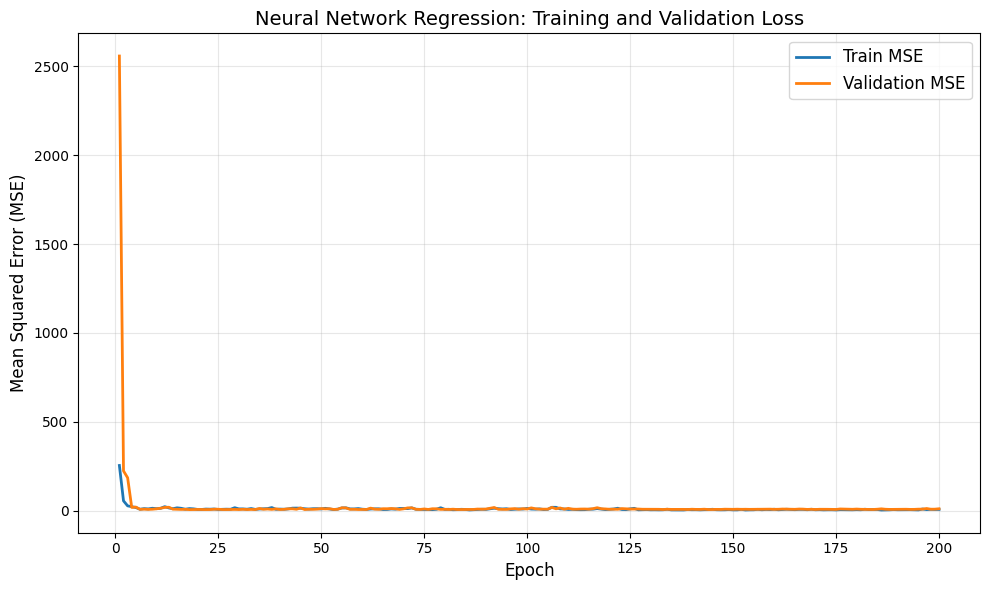

Saved: plots/pytorch_regression_loss_curve.png


In [32]:
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, label="Train MSE", linewidth=2)
plt.plot(epochs_range, val_losses, label="Validation MSE", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.title("Neural Network Regression: Training and Validation Loss", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/pytorch_regression_loss_curve.png", dpi=150)
plt.show()
print("Saved: plots/pytorch_regression_loss_curve.png")

## 8. Test Set Evaluation

Evaluate the final trained model on the held-out test set and report
regression metrics.

In [33]:
test_metrics = evaluate_regression(loader_test, final_model)

print("=" * 50)
print("Neural Network Regression — Test Set Performance")
print("=" * 50)
print(f"  MSE:  {test_metrics['mse']:.4f}")
print(f"  RMSE: {test_metrics['rmse']:.4f}")
print(f"  MAE:  {test_metrics['mae']:.4f}")
print(f"  R²:   {test_metrics['r2']:.4f}")

Neural Network Regression — Test Set Performance
  MSE:  8.8120
  RMSE: 2.9685
  MAE:  2.3243
  R²:   0.8274


## 9. Ground Truth vs Predicted Values Plot

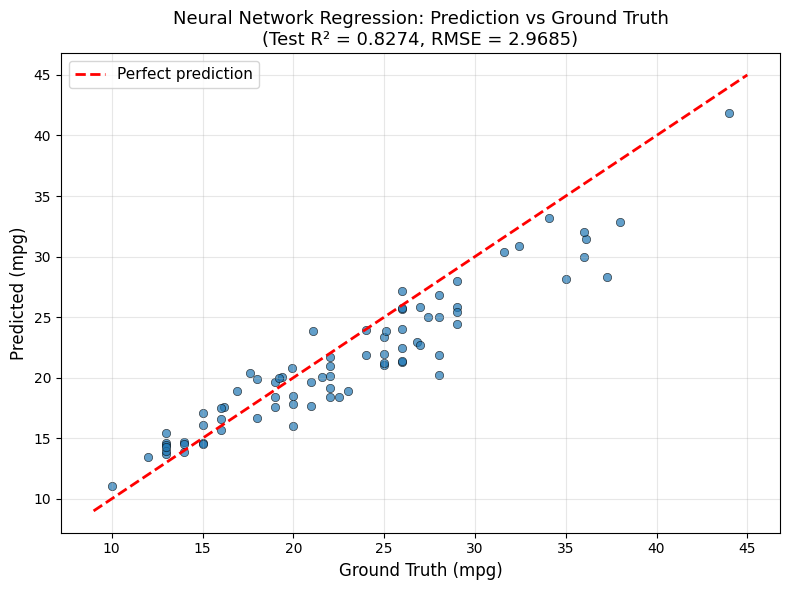

Saved: plots/pytorch_regression_pred_vs_truth.png


In [34]:
# Get predictions on test set
final_model.eval()
with torch.no_grad():
    X_test_dev = X_test_t.to(device=device, dtype=dtype)
    y_pred_test = final_model(X_test_dev).cpu().numpy().flatten()

y_true_test = y_test.values

plt.figure(figsize=(8, 6))
plt.scatter(y_true_test, y_pred_test, alpha=0.7, edgecolors="k", linewidths=0.5)
# Perfect prediction line
lims = [min(y_true_test.min(), y_pred_test.min()) - 1,
        max(y_true_test.max(), y_pred_test.max()) + 1]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
plt.xlabel("Ground Truth (mpg)", fontsize=12)
plt.ylabel("Predicted (mpg)", fontsize=12)
plt.title(f"Neural Network Regression: Prediction vs Ground Truth\n"
          f"(Test R² = {test_metrics['r2']:.4f}, RMSE = {test_metrics['rmse']:.4f})",
          fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/pytorch_regression_pred_vs_truth.png", dpi=150)
plt.show()
print("Saved: plots/pytorch_regression_pred_vs_truth.png")

## 10. Comparison with Part I Baselines

Compare the neural network regression results with the best models from
Part I (`regression_analysis.py`).

In [35]:
# Baseline results from Part I (regression_results.txt)
print("=" * 65)
print(f"{'Model':<30s} {'Test MSE':>10s} {'Test RMSE':>10s} {'Test R²':>10s}")
print("-" * 65)
print(f"{'Linear Regression':<30s} {'10.6100':>10s} {'3.2573':>10s} {'0.7921':>10s}")
print(f"{'Poly Regression (deg=1)':<30s} {'10.6100':>10s} {'3.2573':>10s} {'0.7921':>10s}")
print(f"{'KNN (k=39)':<30s} {'10.4380':>10s} {'3.2308':>10s} {'0.7955':>10s}")
print(f"{'Neural Network (PyTorch)':<30s} {test_metrics['mse']:>10.4f} {test_metrics['rmse']:>10.4f} {test_metrics['r2']:>10.4f}")
print("=" * 65)

Model                            Test MSE  Test RMSE    Test R²
-----------------------------------------------------------------
Linear Regression                 10.6100     3.2573     0.7921
Poly Regression (deg=1)           10.6100     3.2573     0.7921
KNN (k=39)                        10.4380     3.2308     0.7955
Neural Network (PyTorch)           8.8120     2.9685     0.8274


In [26]:
# Save results to file
with open("results/pytorch_regression_results.txt", "w") as f:
    f.write("Neural Network Regression Results (PyTorch)\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Best hyperparameter config: {best_cfg['name']}\n")
    f.write(f"  Hidden layers: {best_cfg['hidden']}\n")
    f.write(f"  Optimizer: {best_cfg['opt']}\n")
    f.write(f"  Learning rate: {best_cfg['lr']}\n")
    f.write(f"  Weight decay: {best_cfg['wd']}\n")
    f.write(f"  Dropout: {best_cfg['dropout']}\n\n")
    f.write("Test Set Performance:\n")
    f.write(f"  MSE:  {test_metrics['mse']:.4f}\n")
    f.write(f"  RMSE: {test_metrics['rmse']:.4f}\n")
    f.write(f"  MAE:  {test_metrics['mae']:.4f}\n")
    f.write(f"  R²:   {test_metrics['r2']:.4f}\n\n")
    f.write("Comparison with Part I Baselines:\n")
    f.write("-" * 65 + "\n")
    f.write(f"{'Model':<30s} {'Test MSE':>10s} {'Test RMSE':>10s} {'Test R²':>10s}\n")
    f.write("-" * 65 + "\n")
    f.write(f"{'Linear Regression':<30s} {'10.6100':>10s} {'3.2573':>10s} {'0.7921':>10s}\n")
    f.write(f"{'Poly Regression (deg=1)':<30s} {'10.6100':>10s} {'3.2573':>10s} {'0.7921':>10s}\n")
    f.write(f"{'KNN (k=39)':<30s} {'10.4380':>10s} {'3.2308':>10s} {'0.7955':>10s}\n")
    f.write(f"{'Neural Network (PyTorch)':<30s} {test_metrics['mse']:>10.4f} {test_metrics['rmse']:>10.4f} {test_metrics['r2']:>10.4f}\n")
    f.write("-" * 65 + "\n")

print("Results saved to: results/pytorch_regression_results.txt")

Results saved to: results/pytorch_regression_results.txt
